# **Weighted KNN**

## **Project:**

- Movie Recommendation System

## **Problem Statement:**

- Recommend movies by giving higher importance to closely related users.Project:




In [16]:
# Step No 1 : Importing Required Library

# Import numerical library 
import numpy as np 

# Import pandas library
import pandas as pd 

# Import Plotting Library 
import matplotlib.pyplot as plt 

# Import Seaborn Library 
import seaborn as sns

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Scaler 
from sklearn.preprocessing import StandardScaler

# Import Weighted KNN Regressor 
from sklearn.neighbors import KNeighborsRegressor

# Import evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [17]:
# Step No 2 : Loading Dataset 
df = pd.read_csv("movie_recommendation_dataset.csv")

In [18]:
# Step No 3 : Data Preprocessing and Analysing 

# Display first rows 
print(df.head())

# Display statistical summary 
print(df.describe())

# Display dataset information 
print(df.info())

   UserID  Age  Action  Comedy  Drama  SciFi  MovieRating
0       1   22       5       3      2      4          4.5
1       2   25       4       4      3      5          4.2
2       3   28       2       5      4      3          3.8
3       4   30       5       2      3      5          4.7
4       5   35       3       4      5      2          3.9
           UserID         Age      Action      Comedy       Drama       SciFi  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    50.500000   32.140000    3.700000    3.790000    3.560000    3.700000   
std     29.011492    7.157704    1.105542    1.085208    1.085441    1.105542   
min      1.000000   21.000000    2.000000    2.000000    2.000000    2.000000   
25%     25.750000   26.000000    3.000000    3.000000    3.000000    3.000000   
50%     50.500000   30.000000    4.000000    4.000000    3.500000    4.000000   
75%     75.250000   38.000000    5.000000    5.000000    5.000000    5.000000   
max 

In [19]:
# Step No 4 : Dataset Cleaning 

# Check missing values 
print(df.isnull().sum())

# Check duplicate rows
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

UserID         0
Age            0
Action         0
Comedy         0
Drama          0
SciFi          0
MovieRating    0
dtype: int64
0


In [20]:
# Step No 5 : Define input features and target variable

# Define input features
X = df[[
    "Age",
    "Action",
    "Comedy",
    "Drama",
    "SciFi"
]]

# Define target variable
y = df["MovieRating"]

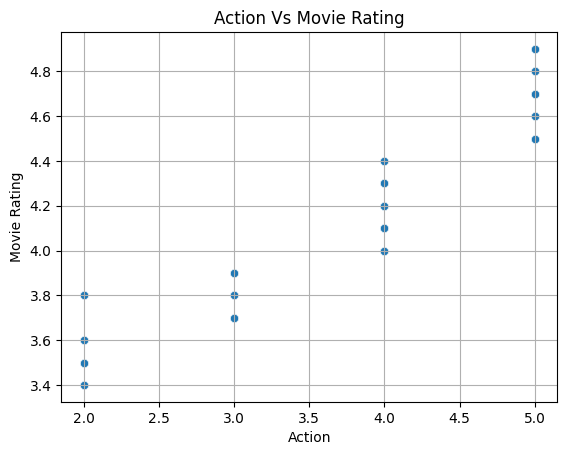

In [21]:
# Step No 6 : Create Scatter plot 
sns.scatterplot(
    x = "Action",
    y = "MovieRating",
    data = df
)

# Set Title 
plt.title("Action Vs Movie Rating")

# Set X Label
plt.xlabel("Action")

# Set Y Label 
plt.ylabel("Movie Rating")

# Enable Grid 
plt.grid()

# Save figure 
plt.savefig("images/Action Vs Movie Rating(Whighted KNN Regressor).png")

# Display the plot 
plt.show()

In [22]:
# Step No 7 : Split Dataset 
X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y , 
    test_size=0.2,
    random_state=42
)

In [23]:
# Step No 8 : Create Scalling 
scaler = StandardScaler()

In [24]:
# Step No 9 : Fit and Transform Training and Testing Data
from sklearn.preprocessing import StandardScaler
# Fit and Transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data 
X_test = scaler.transform(X_test)

In [25]:
# Step No 10 : Create Weighted KNN model 
model = KNeighborsRegressor(
    n_neighbors= 5,
    weights="distance"
)

# weights = "distance"
# Nearby users get higher importance

In [26]:
# Step No 11 : Train Model 
model.fit(X_train , y_train)

KNeighborsRegressor(weights='distance')

In [27]:
# Step No 12 : Predict Movie ratings
y_pred =model.predict(X_test)

# Display predictions 
print("Predicted Movie Ratings : ")
print(y_pred)

Predicted Movie Ratings : 
[4.7 4.7 4.6 4.  3.6 3.5 3.9 4.8 4.6 4.5 4.1 4.5 4.9 4.7 4.5 3.9 4.7 3.9
 4.3 4.2]


In [28]:
# Step No 13 : Evaluation Metrices

# Calculate MAE 
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Calculate MSE
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE 
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

# Calculate R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
0.0
Mean Squared Error : 
0.0
Root Mean Squared Error : 
0.0
R2 Score : 
1.0


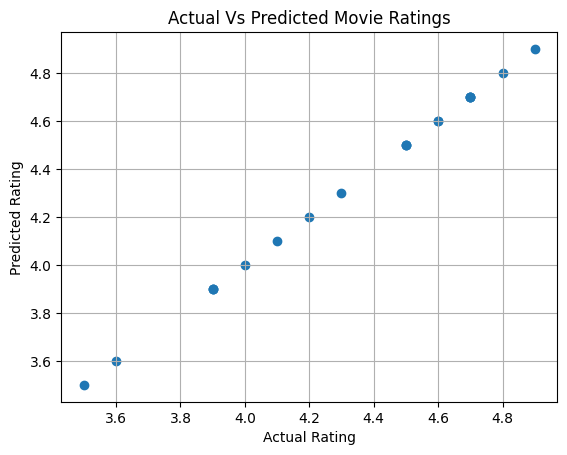

In [29]:
# Step No 14 : Creating Plot Actual Vs Predicted Movie Rating  

plt.scatter(y_test , y_pred)

# Set title 
plt.title("Actual Vs Predicted Movie Ratings")

# Set x label 
plt.xlabel("Actual Rating")

# Set y label 
plt.ylabel("Predicted Rating")

# Enable grid 
plt.grid()

# Save figure 
plt.savefig("images/Actual Vs Predicted Movie Ratings(Weighted KNN Regressor).png")

# Show Plot 
plt.show()

In [30]:
# Step No 15 : Take Input Users

# Take age input 
age = int(input("Enter Age : ")) 

# Take action preference
action = int(input("Enter Action Rating (1-5) : "))

# Take comedy preference 
comedy = int(input("Enter Comedy Rating (1-5) : "))

# Take drama preference 
drama = int(input("Enter Drama Rating : (1-5) : "))

# Take scifi prefrence
scifi = int(input("Enter SciFi Rating (1-5) : "))

In [31]:
# Step No 16 : Create User Dataframe
user_data = pd.DataFrame({
    "Age": [age],
    "Action": [action],
    "Comedy": [comedy],
    "Drama": [drama],
    "SciFi": [scifi]
})

In [32]:
# Step No 17 : Scale user input 
user_data = scaler.transform(user_data)

In [33]:
# Step No 18 : Predict Movie Rating 
result = model.predict(user_data)

In [34]:
# Step No 19 : Display final Output 
print(f"Predicted Movie Rating is : {result[0]:.2f}")

Predicted Movie Rating is : 4.32
